In [2]:
import pandas as pd
import cv2
import numpy as np
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from src.blank_detect import is_blank

In [3]:
BASE_DIR = Path.cwd()
CSV_PATH = BASE_DIR / "data" / "output" / "dataset" / "labels.csv"
IMG_DIR = BASE_DIR / "data" / "output" / "dataset" / "images"

In [4]:
df = pd.read_csv(CSV_PATH)

images = []
labels = df["is_blank"].values

In [5]:
for filename in df["filename"]:
    img_path = str(IMG_DIR / filename)
    
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE) 
    
    if img is None:
        print(f"Warning: Could not read {img_path}")
        continue
        
    images.append(img)

In [6]:
X_data = np.array(images)
y_data = labels

print(f"Images array shape: {X_data.shape}")
print(f"Labels array shape: {y_data.shape}")

Images array shape: (500, 500, 500)
Labels array shape: (500,)


In [13]:
df['detected_blank'] = [
    int(is_blank(cv2.imread(str(IMG_DIR / f)), lower_threshold=0.005)) 
    for f in df['filename']
]

In [14]:
y_true = df['is_blank']
y_pred = df['detected_blank']

print("--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=['Not Blank (0)', 'Blank (1)']))

--- Classification Report ---
               precision    recall  f1-score   support

Not Blank (0)       1.00      0.59      0.75       395
    Blank (1)       0.40      1.00      0.57       105

     accuracy                           0.68       500
    macro avg       0.70      0.80      0.66       500
 weighted avg       0.87      0.68      0.71       500



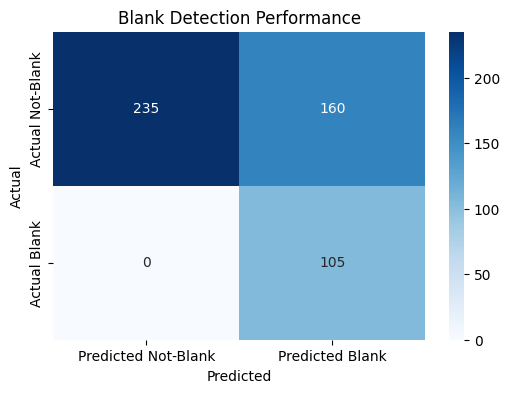

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Not-Blank', 'Predicted Blank'],
            yticklabels=['Actual Not-Blank', 'Actual Blank'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Blank Detection Performance')
plt.show()